# COMSOL Geometry Preparation for a Coupled Quarter-Wave Resonator

::::{admonition} Required extras
:class: tip

This notebook needs the `comsol` extra:

```bash
uv add "qpdk[comsol]"
# or, from a checkout of this repository:
uv sync --extra comsol
# or with pip:
pip install "qpdk[comsol]"
```

Installing the extra installs `MPh`, the Python client for COMSOL, and nothing
else. **It does not install COMSOL and it does not grant a license.** A COMSOL
installation and license are required to build a model; solving the RF
problem also requires the RF Module. Google Colab has neither, so these cells cannot
produce a mesh or a solution there.

See the {ref}`extras reference <notebook-extras>` for what each extra installs.
::::

```{warning}
**Scope of this notebook: geometry only.**

`qpdk.simulation` provides two functions for COMSOL:

- {py:func}`~qpdk.simulation.comsol_layout.prepare_comsol_layout` extracts
  M1 metal polygons (holes preserved), feed ports, and a bounding box from a
  gdsfactory component.
- {py:func}`~qpdk.simulation.comsol.build_comsol_cpw_model` imports those
  polygons into an MPh/COMSOL model as a 3D extruded solid.

Neither function adds a substrate, an air domain, materials, RF physics,
ports, a mesh, or a study. What you get by the end of this notebook is an
**unsolved geometry project**. It is not a COMSOL resonator simulation and it
does not produce an $S_{21}$ curve. Any $S_{21}$ numbers require the extra
modelling steps described in the continuation section below, done by you in
the COMSOL GUI or through the COMSOL Java API.
```

## What is being modelled

The device is a QPDK
{py:func}`~qpdk.cells.quarter_wave_resonator_coupled`: a
meandering coplanar-waveguide (CPW) resonator placed alongside a straight
feedline, separated by a coupling gap. This is the standard hanger geometry
used to read out superconducting qubits {cite:p}`gopplCoplanarWaveguideResonators2008a`.

Two terminations define a **quarter-wave** resonator:

- The end nearest the feedline is **open**. Charge accumulates there, so the
  voltage has an antinode and the current a node.
- The far end is **shorted**. Current has an antinode and the voltage a node.

A line with one open and one shorted end resonates when its electrical length
is an odd multiple of $\lambda/4$. Close to resonance the coupling capacitor
loads the feedline, and the feedline transmission $|S_{21}|$ shows a **narrow
notch**: at the resonant frequency, power that would travel from `coupling_o1`
to `coupling_o2` is largely reflected through interference with the resonator
response. Material and radiation losses can also absorb some power. The
depth and width of the notch give the coupling and the loaded
quality factor; its centre frequency gives $f_r$.

### Why this problem is harder than it looks

- **Lossless metal is the starting approximation.** The QPDK metal is a
  superconductor, but the first COMSOL model should treat the metal as a
  perfect electric conductor (PEC). PEC has zero surface resistance, so it
  predicts no conductor loss, and it also ignores the **kinetic inductance**
  of the superconducting film. PEC is a useful first approximation for
  checking geometry and coupling; a measured frequency or quality factor
  cannot be predicted from it alone.
- **The resonance is narrow.** A hanger resonator can reach $Q \sim 10^4$ to
  $10^6$, so the fractional linewidth $f_r/Q$ can be $10^{-4}$ or smaller. A
  frequency sweep that is wide enough to see the mode is far too coarse to
  resolve it. This is why the COMSOL reference workflow below first searches
  for the eigenfrequency and then runs a **narrow** sweep around it rather than
  sweeping a broad band on a uniform grid.
- **The mesh must resolve the small features.** The electromagnetic field
  concentrates in the CPW gaps (a few µm) and near the metal edges. The
  extruded metal is only `0.2 µm` thick, three orders of magnitude thinner
  than a 500 µm silicon substrate, so a naive tetrahedral mesh over the whole
  domain produces badly shaped elements at the metal. Refine the gap region
  and the metal explicitly, and check convergence of $f_r$ under mesh
  refinement before trusting any number.
- **Frequency and mesh sensitivity interact.** Because the notch is narrow,
  both an under-resolved mesh and an under-resolved sweep look like a shifted
  or shallow dip. The two must be checked separately.

### The COMSOL reference model

COMSOL's own RF example ["Coplanar Waveguide Resonator"](https://www.comsol.com/model/download/953251/models.rf.cpw_resonator.pdf)
is the natural companion for this geometry. Its workflow is:

1. A 3D domain made of silicon plus an enclosing air region.
2. **Numeric TEM ports** on the feedline cross-sections at the model boundary,
   each with a **voltage integration line** (an edge running from ground to the
   centre conductor) that defines the port voltage.
3. **Boundary mode analysis** study steps, one per port, that solve the 2D
   cross-section eigenmode and supply the port mode field.
4. An **eigenfrequency** study to locate the resonator mode, followed by a
   **narrow, adaptive frequency-domain sweep** around it to produce the
   transmission notch.

**The entity IDs in that model are properties of its geometry.** Its port
boundaries, PEC boundaries, scattering boundaries, and integration edges are
numbered according to its own building sequence and dimensions. Those numbers
are meaningless in this layout, and copying COMSOL Java/`physics.create`
calls with hardcoded selections from the reference into this model will
silently attach boundary conditions to the wrong faces. Every selection in
this notebook's geometry must be made by you, by inspecting the actual faces
and edges in the COMSOL GUI (or by selecting them geometrically through the
Java API).

**References:**
- [COMSOL "Coplanar Waveguide Resonator" model](https://www.comsol.com/model/download/953251/models.rf.cpw_resonator.pdf)
- [MPh tutorial](https://mph.readthedocs.io/en/stable/tutorial.html)
- MPh repository: https://github.com/MPh-py/MPh

## Setup and imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[comsol] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])
    print(
        "Note: this installs the Python client only. COMSOL itself and its "
        "license are not pip-installable, so the modelling cells below cannot "
        "run in Colab."
    )

In [2]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

from qpdk import PDK
from qpdk.cells.resonator import quarter_wave_resonator_coupled
from qpdk.simulation import build_comsol_cpw_model, prepare_comsol_layout
from qpdk.tech import coplanar_waveguide

try:
    import mph
except ImportError:
    mph = None

PDK.activate()

MPH_AVAILABLE = mph is not None
if not MPH_AVAILABLE:
    print(
        "MPh is not installed. The COMSOL cells in this notebook will be "
        "skipped. Install it with `uv sync --extra comsol`."
    )

## Build the coupled quarter-wave resonator

The component is created with an explicit CPW cross-section so that the
centre-conductor width and the gap are known constants we can reuse when
describing the port planes later.

In [3]:
CPW_WIDTH_UM = 10.0
CPW_GAP_UM = 6.0
cross_section = coplanar_waveguide(width=CPW_WIDTH_UM, gap=CPW_GAP_UM)

component = quarter_wave_resonator_coupled(
    length=4000.0,
    meanders=4,
    cross_section=cross_section,
    cross_section_non_resonator=cross_section,
    coupling_straight_length=200.0,
    coupling_gap=20.0,
)

print(f"Component: {component.name}")
print(f"Bounding box: {component.bbox()}")
for port in component.ports:
    print(
        f"  {port.name}: center={tuple(round(value, 3) for value in port.center)} µm, "
        f"width={port.width} µm, orientation={port.orientation}°"
    )

Component: quarter_wave_resonator_coupled_L4000_M4_BSbend_circular_6511fe66
Bounding box: (-104.939,-841;665.663,11)
  resonator_o1: center=(0.0, -30.0) µm, width=22.0 µm, orientation=180.0°
  coupling_o1: center=(0.0, 0.0) µm, width=10.0 µm, orientation=180.0°
  coupling_o2: center=(200.0, 0.0) µm, width=10.0 µm, orientation=0.0°


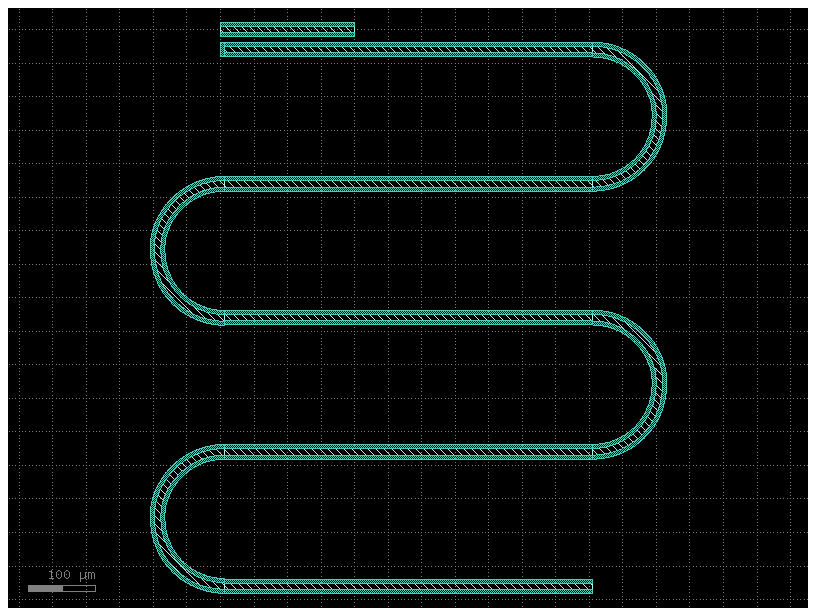

In [4]:
# 2D layout preview
component.plot()

Note the ports: `coupling_o1` and `coupling_o2` are the two ends of the
feedline and are the natural S-parameter reference planes. `resonator_o1` is
the open end of the resonator; the shorted end has no port.

The feedline port width is reported as the **centre-conductor width only**
(`10 µm`). The gap and the ground plane are not part of that number, which
matters when the port plane is placed.

## Extract the COMSOL layout

{py:func}`~qpdk.simulation.comsol_layout.prepare_comsol_layout` folds the
additive metal into the etch layer, inverts the mask around the component
bounding box, applies a ground margin, and returns positive M1 metal. The
result is the metal of the chip: a large ground plane with the CPW gaps cut
out of it. The input needs an M1_ETCH mask to define those gaps; a positive
M1_DRAW shape alone cannot identify them.

In [5]:
GROUND_MARGIN_UM = 100.0

layout = prepare_comsol_layout(
    component,
    feed_ports=("coupling_o1", "coupling_o2"),
    ground_margin=GROUND_MARGIN_UM,
)

hole_count = sum(len(polygon.holes) for polygon in layout.polygons)
print(f"Metal polygons: {len(layout.polygons)} ({hole_count} holes total)")
print(f"Prepared bounding box (µm): {layout.bbox}")
print(f"  width = {layout.bbox.width:.3f} µm, height = {layout.bbox.height:.3f} µm")
for feed in layout.feed_ports:
    print(
        f"Feed {feed.name}: center={feed.center} µm, width={feed.width} µm, "
        f"orientation={feed.orientation}°"
    )

Metal polygons: 1 (3 holes total)
Prepared bounding box (µm): ComsolBoundingBox(xmin=-204.939, ymin=-941.0, xmax=765.663, ymax=111.0)
  width = 970.602 µm, height = 1052.000 µm
Feed coupling_o1: center=(0.0, 0.0) µm, width=10.0 µm, orientation=180.0°
Feed coupling_o2: center=(200.0, 0.0) µm, width=10.0 µm, orientation=0.0°


### Holes are preserved

The CPW gaps are *holes* in the ground-plane polygon, not separate outlines.
`ComsolPolygon` therefore stores `outline` and `holes` separately:
`outline` alone is the complete shape only when `holes` is empty, and a
consumer that accepts a single COMSOL polygon point list has to subtract the
holes itself. `build_comsol_cpw_model` does exactly that, emitting one
`Difference` feature per hole.

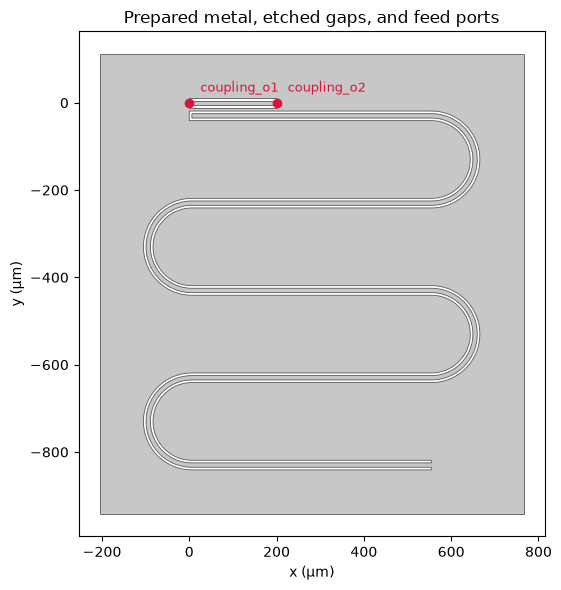

In [6]:
# Visualise the prepared metal, its holes, and the feed port locations. The
# ground plane dominates the extent, so this is an overview rather than a
# close-up of the CPW gaps.
fig, ax = plt.subplots(figsize=(6, 6))
for polygon in layout.polygons:
    ax.add_patch(
        MplPolygon(
            polygon.outline,
            closed=True,
            facecolor="0.78",
            edgecolor="0.35",
            linewidth=0.6,
            zorder=1,
        )
    )
    for hole in polygon.holes:
        ax.add_patch(
            MplPolygon(
                hole,
                closed=True,
                facecolor="white",
                edgecolor="0.35",
                linewidth=0.6,
                zorder=2,
            )
        )
for feed in layout.feed_ports:
    ax.plot(*feed.center, marker="o", color="crimson", markersize=6, zorder=4)
    ax.annotate(
        feed.name,
        feed.center,
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=9,
        color="crimson",
    )
ax.set_aspect("equal")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title("Prepared metal, etched gaps, and feed ports")
plt.tight_layout()
plt.show()

### Where the port planes have to go

`prepare_comsol_layout` reports the feed ports exactly as they appear on the
component and asserts nothing about where they sit relative to the prepared
ground plane. That is deliberate: after the mask inversion the ground plane
**surrounds** the feeds, so a feed centre can easily lie several hundred
micrometres inside the bounding box, as it does here. Valid port boundaries
still have to be constructed before the RF study can run.

The source feed locations at $x = 0$ and $x = 200$ are **inside** the prepared
region. Cropping the whole model there would remove much of the resonator;
cropping only the dielectric would leave ground metal across the port faces.
Before assigning numeric TEM ports, extend the feed conductor *and both CPW
gap strips* from each source feed to separate exterior faces beyond the entire
resonator. Terminate the metal, substrate, and air consistently at those
faces. A port face must cover the conductor, both gaps, and some ground on
either side. Route the extensions away from the resonator so they do not
lengthen the intended coupling region; if that is impossible, include the
extra coupled length when comparing with the analytical layout model. The
current builder does not make these extensions; make and
inspect them in COMSOL before adding RF physics. The table below records the
source feed locations and minimum CPW width to carry into that work.

In [7]:
for feed in layout.feed_ports:
    # Orientation is cardinal: 0°/180° means the line runs along x, so the port
    # plane's normal is x and the transverse direction is y (and vice versa).
    along_x = math.isclose(feed.orientation % 180.0, 0.0, abs_tol=1e-6)
    normal_axis = "x" if along_x else "y"
    plane_position = feed.center[0] if along_x else feed.center[1]
    half_span = feed.width / 2.0 + CPW_GAP_UM
    print(f"{feed.name}:")
    print(f"  source feed:     {normal_axis} = {plane_position:.3f} µm")
    print(f"  plane normal:    ±{normal_axis}")
    print(
        f"  transverse span: more than ±{half_span:.1f} µm about the port centre "
        f"({feed.width:.1f} µm conductor + {CPW_GAP_UM:.1f} µm gap each side)"
    )
    print("  voltage integration line: ground edge to centre conductor, on this face")

coupling_o1:
  source feed:     x = 0.000 µm
  plane normal:    ±x
  transverse span: more than ±11.0 µm about the port centre (10.0 µm conductor + 6.0 µm gap each side)
  voltage integration line: ground edge to centre conductor, on this face
coupling_o2:
  source feed:     x = 200.000 µm
  plane normal:    ±x
  transverse span: more than ±11.0 µm about the port centre (10.0 µm conductor + 6.0 µm gap each side)
  voltage integration line: ground edge to centre conductor, on this face


## Build the COMSOL geometry project

{py:func}`~qpdk.simulation.comsol.build_comsol_cpw_model` starts MPh, creates a
3D component, draws each polygon outline on work plane `wp1`, subtracts each
hole with its own `Difference` feature, and extrudes the work plane by the
metal thickness. It then runs the geometry sequence and returns the model.

`mph.start(cores=...)` launches a COMSOL server process and attaches to it.
**Only one MPh client can exist per Python process**, and the call needs a
COMSOL installation and a license. **The run is off by default** so the
notebook executes while building the documentation; set `RUN_COMSOL = True`
on a licensed machine to build and save the model.

The output path is outside the repository by default. Change it to a location
with enough space for the saved model.

In [8]:
RUN_COMSOL = False
MODEL_DIR = Path.home() / "comsol_models"
MODEL_PATH = MODEL_DIR / "comsol_cpw_resonator.mph"
COMPLETED_MODEL_PATH = MODEL_DIR / "comsol_cpw_resonator_solved.mph"
METAL_THICKNESS_UM = 0.2
CORES = 4

client = None
model = None

if not RUN_COMSOL:
    print(
        "RUN_COMSOL is False, so no COMSOL process was started. Set it to True "
        "on a machine with COMSOL and a license to build the geometry project."
    )
elif not MPH_AVAILABLE:
    print("MPh is not installed, so no COMSOL model was created.")
else:
    try:
        MODEL_DIR.mkdir(parents=True, exist_ok=True)
        client = mph.start(cores=CORES)
        model = build_comsol_cpw_model(
            client,
            layout,
            metal_thickness_um=METAL_THICKNESS_UM,
            name="QPDK Coupled Quarter-Wave Resonator",
        )
        model.save(MODEL_PATH)
        print(f"Saved geometry project to {MODEL_PATH}")
    except Exception as error:  # COMSOL missing, not licensed, or busy
        print(f"COMSOL geometry build did not run: {error!r}")

RUN_COMSOL is False, so no COMSOL process was started. Set it to True on a machine with COMSOL and a license to build the geometry project.


### Inspect what the builder produced

MPh exposes the model structure through thin wrappers over the COMSOL Java
API. At this point the model contains exactly one component, one 3D geometry
with a work plane and an extrude, and **no** physics, materials, mesh, or
study. The `problems()` call is the cheapest way to find out whether COMSOL
itself is unhappy with what was built.

In [9]:
if model is not None:
    print(f"components: {model.components()}")
    print(f"geometries: {model.geometries()}")
    print(f"problems:   {model.problems()}")
    print(
        "Not yet present (by design): "
        f"physics={model.physics()}, materials={model.materials()}, "
        f"studies={model.studies()}"
    )
else:
    print("No model to inspect.")

No model to inspect.


## How MPh relates to COMSOL

MPh keeps a COMSOL server session
alive from Python and forwards calls to the COMSOL Java API through `model.java`.
Anything you can do in the GUI can be scripted this way, but nothing is done
for you. The geometry above was created through a COMSOL **work plane**, which
means the QPDK polygons are ordinary 2D geometry: no ECAD or layout-import
license is needed to build them.

The saved `.mph` file is a normal COMSOL model file. You can open it directly
in the COMSOL Desktop GUI and continue from there, which is the recommended
path for the physics setup. Use `model.java.<...>` from Python only once you
know the selection you want, and prefer selecting faces and edges
geometrically (by coordinates or by a named selection) over copying numeric
entity IDs from another model.

## Continuing in the COMSOL GUI

The steps below are what turn the geometry project into an RF simulation. Do
them in the GUI, where you can see the selections you are making.

1. **Add the material domains.** Create a silicon block under the metal
   (typically 500 µm thick) and an air region above it, both large enough that
   the fields have decayed before reaching the outer boundary. For this layout
   extend the feed conductor and gaps to exterior faces beyond the resonator
   as described above.
2. **Assign PEC to the metal faces.** `Extrude 1` selects the metal by
   geometry, but the PEC boundary condition must reference the *actual* faces
   of that extruded solid, which is only visible once the substrate and air
   domains exist. Do not paste boundary numbers from the reference model.
3. **Assign a scattering boundary condition to the exterior**, so the domain
   behaves as if it extends to infinity and does not reflect.
4. **Add two numeric TEM ports**, one on each feed plane, with port type
   `Numeric`. Each port needs a **voltage integration line**: an edge on the
   port face running from the ground conductor to the centre conductor. Create
   those edges explicitly, or the port solver cannot define the mode voltage.
   The port's transverse extent must cover conductor *and* gap on both sides,
   per the checklist.
5. **Add two boundary mode analysis study steps**, one per port, to solve the
   2D cross-section eigenmode that defines each port's TEM field.
6. **Add an eigenfrequency study** to locate the quarter-wave resonance in a
   band around your analytical estimate, then a **frequency-domain study with
   a narrow sweep** spanning a few linewidths around it. Enable the adaptive
   frequency sweep so COMSOL refines where the notch is.
7. **Check convergence**: refine the mesh in the CPW gaps and around the metal,
   re-solve, and confirm that $f_r$ and the notch depth stop moving. Report
   $Q$ only after that.

Keep the metal as PEC for the first pass. Once the geometry and coupling are
trusted, replace it with a surface-impedance or transition boundary condition
using the superconductor's surface resistance $R_s$ and kinetic inductance
$L_k$ to get a realistic, finite $Q$.

## Running the solver headlessly

A complete model can be solved without the GUI, which is useful for batches
and for moving the solve to a bigger machine. COMSOL ships a `comsol batch`
command for exactly this:

```bash
comsol batch \
    -inputfile cpw_resonator.mph \
    -outputfile cpw_resonator_solved.mph \
    -study std1 \
    -np 4 \
    -tmpdir ./comsol_tmp
```

- `-inputfile` is the model to solve, `-outputfile` is where the solved model
  (geometry, settings, **and** solutions) is written. Point it somewhere you
  have space, and keep it as the file the next cell loads.
- `-study` takes the study **tag** (such as `std1`), which may differ from
  the label shown in the GUI. Inspect `model.java.study().tags()` to find it.
  Drop this option to run every study in the model.
- `-np` is the number of compute cores. Full-wave 3D RF solves are
  memory-bound, so check that `-np` times the per-core memory estimate fits in
  RAM before raising it.
- `-tmpdir` should be a fast local disk with room for the solver's temporary
  files, not a network mount.

The same command runs anywhere COMSOL is installed; there is nothing
site-specific about it.

## Loading and evaluating a completed model

Everything below only runs if a solved `.mph` exists at
`COMPLETED_MODEL_PATH`. Without one, the notebook still runs to this point and
simply reports that there is nothing to show. **Anything printed here is a
real solver output only if you actually produced a solved model.**

In [10]:
RUN_SOLVE = False
STUDY_NAME = "Study 1"
DATASET_NAME = None  # Set this to a name printed by solved_model.datasets().
S21_EXPRESSION = "emw.S21dB"

solved_model = None
frequencies_ghz = None
s21_db = None

if MPH_AVAILABLE and client is not None and COMPLETED_MODEL_PATH.exists():
    solved_model = client.load(COMPLETED_MODEL_PATH)
    studies = solved_model.studies()
    datasets = solved_model.datasets()
    print(f"studies:  {studies}")
    print(f"datasets: {datasets}")

    if RUN_SOLVE and STUDY_NAME in studies:
        print(f"Solving study {STUDY_NAME!r}...")
        solved_model.solve(STUDY_NAME)
        solved_model.save(COMPLETED_MODEL_PATH)
        datasets = solved_model.datasets()
        print(f"datasets after solve: {datasets}")

    if DATASET_NAME is None:
        print("Choose DATASET_NAME from the datasets listed above to evaluate S21.")
    elif DATASET_NAME not in datasets:
        print(f"Dataset {DATASET_NAME!r} is not in this model: {datasets}")
    else:
        print(f"Evaluating on dataset {DATASET_NAME!r}")
        try:
            frequencies_ghz = solved_model.evaluate("freq", dataset=DATASET_NAME) / 1e9
            s21_db = solved_model.evaluate(S21_EXPRESSION, dataset=DATASET_NAME)
        except Exception as error:
            print(f"Evaluation failed for {S21_EXPRESSION!r}: {error!r}")
            print(
                "The expression name is model-specific. Check the variable name "
                "under Results in the COMSOL GUI and update S21_EXPRESSION."
            )
else:
    print(f"No completed model named {COMPLETED_MODEL_PATH.name!r} in MODEL_DIR")
    print(
        "Set up the physics and study in the COMSOL GUI (or run `comsol batch`), "
        "save the solved model to that path, then re-run this cell."
    )
    print("No S-parameters were computed, so none are shown.")

No completed model named 'comsol_cpw_resonator_solved.mph' in MODEL_DIR
Set up the physics and study in the COMSOL GUI (or run `comsol batch`), save the solved model to that path, then re-run this cell.
No S-parameters were computed, so none are shown.


`emw.S21dB` is the S-parameter variable name this notebook assumes. If your
model defines the S-parameter evaluation under a different name, or if the
frequency axis lives on a different dataset, edit `S21_EXPRESSION` and the
`DATASET_NAME`. `model.inner(dataset)` and `model.outer(dataset)` return
the sweep indices and values directly if the `freq` expression is not
available on the selected dataset.

In [11]:
if s21_db is not None and frequencies_ghz is not None:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(frequencies_ghz, s21_db)
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel(r"$|S_{21}|$ (dB)")
    ax.set_title("Feedline transmission from the completed COMSOL model")
    ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No simulated transmission data, so there is nothing to plot.")

No simulated transmission data, so there is nothing to plot.


## Summary

What this notebook did, end to end:

1. Built a QPDK `quarter_wave_resonator_coupled` component with an explicit
   CPW cross-section and identified its feedline ports.
2. Extracted `ComsolLayout` metal polygons via `prepare_comsol_layout`,
   showing that the ground plane dominates the bounding box, the CPW gaps
   survive as polygon holes, and the feed centres sit inside the prepared
   domain rather than on its edge.
3. Built an **unsolved** 3D geometry project with
   `build_comsol_cpw_model` and saved it as a `.mph` file that opens in the
   COMSOL GUI.
4. Inspected the model structure with MPh to confirm that geometry is all
   that exists, and printed the source feed coordinates for the physics setup.
5. Described the continuation - materials, PEC and scattering boundaries,
   numeric TEM ports with voltage integration lines, boundary mode analysis,
   eigenfrequency search, and a narrow frequency sweep - and showed how to
   load, optionally solve, and evaluate a completed model.

What it did **not** do: it did not add physics, materials, ports, a mesh, or a
study, and it did not compute an $S_{21}$ curve. Output from the evaluation
cell is real only if you produced a solved model yourself.

**Recommended next steps:**

- Follow the COMSOL reference model's workflow for the physics, but make every
  selection on *this* geometry; the reference's entity IDs do not transfer.
- Mesh the CPW gaps and the metal explicitly, then verify that $f_r$ converges
  under refinement before reporting it.
- Compare the PEC result against the QPDK analytical and SAX models in
  {doc}`/notebooks/all_models` as a sanity check on the coupling and frequency.
- Add surface impedance for the superconductor to get a realistic $Q$, and
  compare with measurements.

## References

```{bibliography}
:filter: docname in docnames
```